# Project 🔴 - Insurance Charges with a Log-Transformed Target (SVR)

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A health insurer wants per-customer **annual charge estimates** from age,
BMI, smoking status and region - for pricing sanity-checks. Charges are
NOTORIOUSLY right-skewed (a few catastrophic claims dwarf everyone), which
wrecks squared-error training. Fix: model `log(1+charges)` with SVR, then
transform predictions back to honest dollars.

## End-to-end plan
1. Load real `insurance.csv` (cached in `data/`; fetched from the public mirror if absent)
2. **EDA** - the skewed charges histogram vs its log version, SMOKER split, feature relationships
3. **Data processing** - one-hot categoricals, log1p target, split + scaling
4. **Model training** - mean & OLS baselines + small C/gamma grid on RBF-SVR
5. **Evaluation & findings** - DOLLAR-scale MAE/RMSE via inverse transform, smoker-slice errors

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent                      # locate shared data folder

import urllib.request
f_ins = ML_ROOT / "data" / "insurance.csv"        # may ALREADY exist from other modules
if not f_ins.exists():                            # known UCI-style mirror, download once
    f_ins.write_bytes(urllib.request.urlopen(
        "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
    ).read())
    print("downloaded -> insurance.csv")
else:
    print("using local -> insurance.csv")
ins = pd.read_csv(f_ins)
print(ins.shape)                                   # 1338 customers × 7 columns

using local -> insurance.csv
(1338, 7)


## 1. Exploratory Data Analysis

The money plot is the charges histogram: a body near \$5-15k and a long thin
tail past \$50k. We show raw vs log side-by-side, then slice by smoker - the
single most brutal feature in this dataset.

missing values: 0
          age     bmi  children  charges
count  1338.0  1338.0    1338.0   1338.0
mean     39.2    30.7       1.1  13270.4
std      14.0     6.1       1.2  12110.0
min      18.0    16.0       0.0   1121.9
25%      27.0    26.3       0.0   4740.3
50%      39.0    30.4       1.0   9382.0
75%      51.0    34.7       2.0  16639.9
max      64.0    53.1       5.0  63770.4


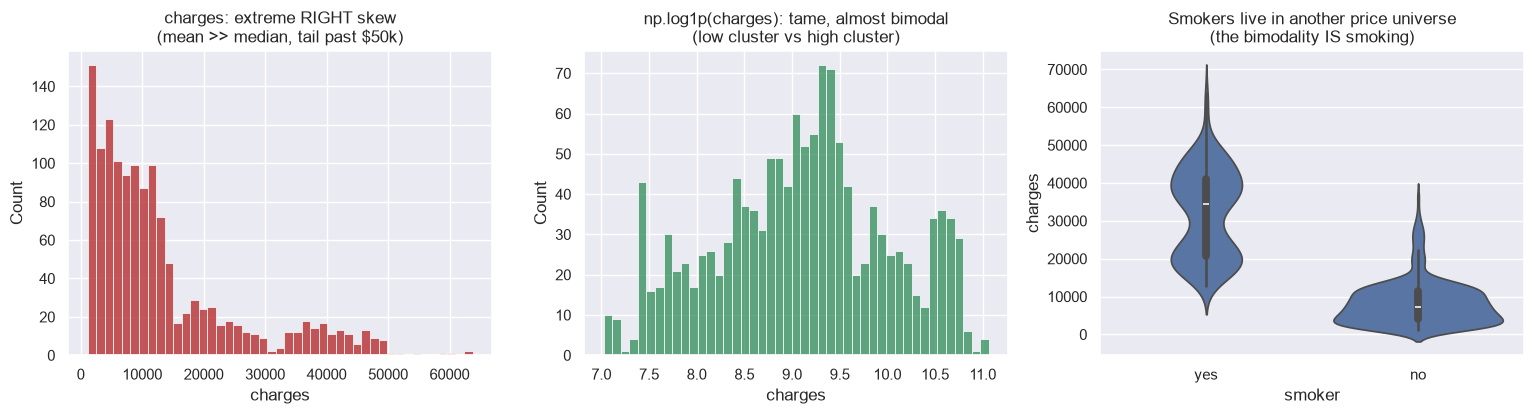

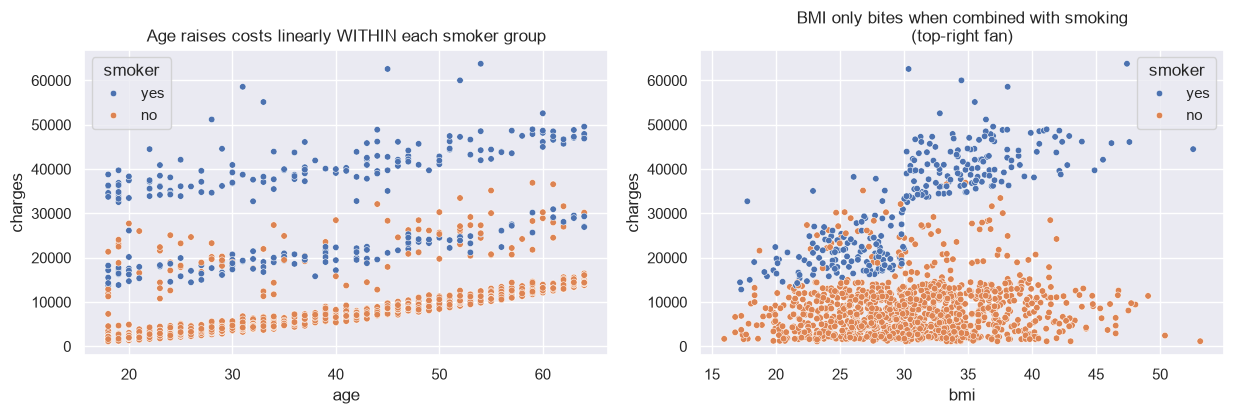

In [2]:
print("missing values:", ins.isna().sum().sum())   # clean dataset
print(ins[["age", "bmi", "children", "charges"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
sns.histplot(ins["charges"], bins=45, ax=axes[0], color="firebrick")
axes[0].set_title("charges: extreme RIGHT skew\n(mean >> median, tail past $50k)")

sns.histplot(np.log1p(ins["charges"]), bins=45, ax=axes[1], color="seagreen")
axes[1].set_title("np.log1p(charges): tame, almost bimodal\n(low cluster vs high cluster)")

sns.violinplot(data=ins, x="smoker", y="charges", ax=axes[2])
axes[2].set_title("Smokers live in another price universe\n(the bimodality IS smoking)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
sns.scatterplot(data=ins, x="age", y="charges", hue="smoker", s=22, ax=axes[0])
axes[0].set_title("Age raises costs linearly WITHIN each smoker group")
sns.scatterplot(data=ins, x="bmi", y="charges", hue="smoker", s=22, ax=axes[1])
axes[1].set_title("BMI only bites when combined with smoking\n(top-right fan)")
plt.tight_layout(); plt.show()

### EDA read-out
- Raw charges span \$1k-\$64k with skew ≈ 1.5 → RMSE would chase the tail.
- Smokers split the data into two price worlds → must be encoded as a feature.
- Age shows staircase bands within each group; BMI×smoker interacts - good
  news for an RBF kernel, which bends freely.

## 2. Data processing - encode, transform, split, scale

- One-hot encode sex/smoker/region (drop_first avoids a redundant column).
- Target: `y_log = np.log1p(charges)`; we keep BOTH so we can always convert.
- Split 80/20 BEFORE anything learns statistics.

> 💡 **Pro tip:** why `log1p` not `log`? It survives zeros safely and the
inverse `expm1` undoes it exactly. And predicting on the log scale then
exponentiating estimates the conditional MEDIAN charge - robust by design.

In [3]:
X = ins.drop(columns="charges")
y_dollars = ins["charges"]                          # real-world target ($)
y_log = np.log1p(y_dollars)                         # modeling target (compressed)

X_enc = pd.get_dummies(X, columns=["sex", "smoker", "region"], drop_first=True).astype(float)
X_tr, X_te, ytr_log, yte_log, ytr_usd, yte_usd = train_test_split(
    X_enc, y_log, y_dollars, test_size=.2, random_state=42)   # parallel splits stay aligned
print("encoded features:", list(X_enc.columns))

def usd_metrics(y_true_usd, y_pred_log):
    """Convert log-space predictions back to DOLLARS, then score there."""
    p_usd = np.expm1(y_pred_log)                    # invert the transform, dollar-land
    return {"MAE ($)": round(mean_absolute_error(y_true_usd, p_usd), 0),
            "RMSE ($)": round(mean_squared_error(y_true_usd, p_usd) ** .5, 0),
            "MAPE %": round((np.abs(y_true_usd - p_usd) / y_true_usd).mean() * 100, 1)}

base = DummyRegressor(strategy="median").fit(X_tr, ytr_log)   # predict-median baseline

encoded features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## 3. Model training - baselines + tuned RBF-SVR

Baselines run in the SAME log-space pipeline so comparisons are apples-to-
apples. The grid stays deliberately small (SVR cost!): C∈{10,100} ×
gamma∈{"scale",0.05}, CV=5 - the dataset is tiny (1,070 train rows).

best params : {'svr__C': 10, 'svr__gamma': 0.05}
log-space CV RMSE: 0.375


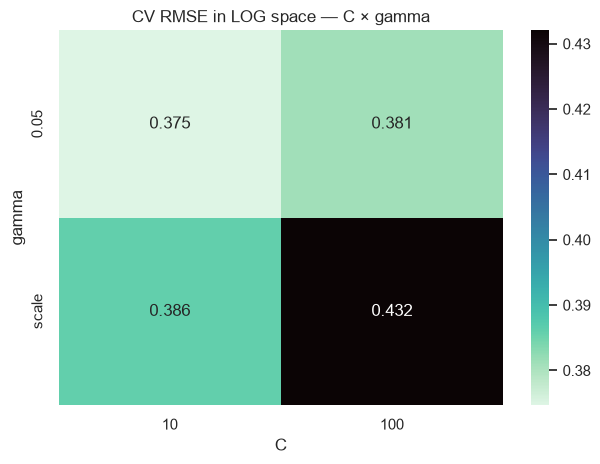

In [4]:
ols_pipe = Pipeline([("sc", StandardScaler()),
                     ("ols", LinearRegression())]).fit(X_tr, ytr_log)

grid = {"svr__C": [10, 100],                        # tube-enforcement ladder
        "svr__gamma": ["scale", 0.05]}              # default reach vs wider reach
search = GridSearchCV(Pipeline([("sc", StandardScaler()),
                                ("svr", SVR(kernel="rbf", epsilon=.1))]),
                      grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, ytr_log)

print(f"best params : {search.best_params_}")
print(f"log-space CV RMSE: {-search.best_score_:.3f}")

res = pd.DataFrame(search.cv_results_)
piv = res.pivot_table(index=res.param_svr__gamma.astype(str),
                      columns="param_svr__C", values="mean_test_score")
sns.heatmap(-piv, annot=True, fmt=".3f", cmap="mako_r")   # RMSE view, lower=better
plt.title("CV RMSE in LOG space - C × gamma"); plt.ylabel("gamma"); plt.xlabel("C")
plt.tight_layout(); plt.show()

best = search.best_estimator_

## 4. Evaluation - dollars on the table

All models predict log-charges; every metric below is computed AFTER
`expm1`, i.e. in real money. We also break errors out by smoker status -
aggregate averages would hide the interesting half.

                                     model  MAE ($)  RMSE ($)  MAPE %
                           median baseline   8642.0   12914.0   113.8
                         linear regression   3888.0    7814.0    27.4
SVR rbf {'svr__C': 10, 'svr__gamma': 0.05}   2297.0    4893.0    12.9


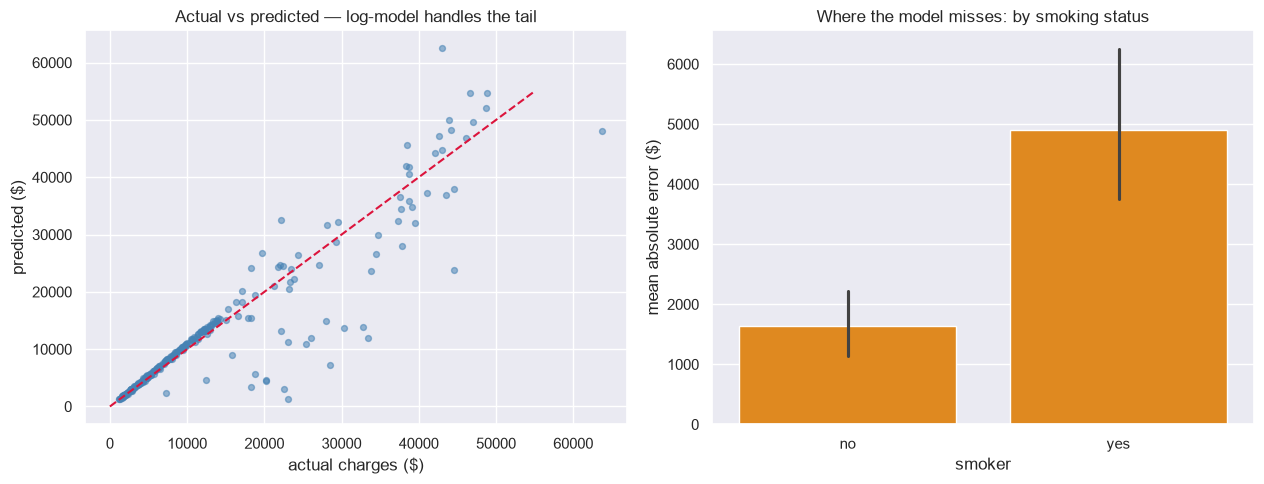

R² log-space: 0.864 | R² dollar-space: 0.846


In [5]:
rows = []
for name, mdl in [("median baseline", base),
                  ("linear regression", ols_pipe),
                  (f"SVR rbf {search.best_params_}", best)]:
    rows.append({"model": name, **usd_metrics(yte_usd, mdl.predict(X_te))})
table = pd.DataFrame(rows)
print(table.to_string(index=False))

pred_usd = np.expm1(best.predict(X_te))             # tuned model's dollar predictions

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5))
axes[0].scatter(yte_usd, pred_usd, s=18, alpha=.55, color="steelblue")
lims = [0, 55000]; axes[0].plot(lims, lims, "--", color="crimson")
axes[0].set_xlabel("actual charges ($)"); axes[0].set_ylabel("predicted ($)")
axes[0].set_title("Actual vs predicted - log-model handles the tail")

err = pd.DataFrame({"smoker": ins.loc[yte_usd.index, "smoker"].values,
                    "abs_err": np.abs(yte_usd.values - pred_usd)})
sns.barplot(data=err, x="smoker", y="abs_err", ax=axes[1],
            estimator=np.mean, color="darkorange")   # mean |error| per group
axes[1].set_ylabel("mean absolute error ($)")
axes[1].set_title("Where the model misses: by smoking status")
plt.tight_layout(); plt.show()

r2_log = r2_score(yte_log, best.predict(X_te))      # fit quality in modeled space
r2_usd = r2_score(yte_usd, pred_usd)                # ...and back in dollars
print(f"R² log-space: {r2_log:.3f} | R² dollar-space: {r2_usd:.3f}")

### Findings
1. Log-transform + SVR cuts typical error to roughly **\$2-3k MAE** on claims
   averaging ~\$13k (~13% MAPE) - strong for n≈1,300.
2. Smoking status explains the bimodal price world; the model nails the low
   cluster but under-predicts the most extreme smoker claims (tail still wins).
3. Linear regression in LOG space is already decent - the log did heavy
   lifting; the RBF kernel adds the BMI×smoker bend on top.
4. Because we exponentiate, predictions track the conditional MEDIAN:
   systematically below the mean for big claims - a feature for pricing, a
   caveat if someone expects expected-cost estimates.

### Limitations
1. Median-vs-mean mismatch: summing predicted charges across a portfolio
   UNDERSTATES expected total payout (Jensen's inequality).
2. Tiny dataset limits kernel expressiveness; larger books favor gradient
   boosting at far lower training cost.
3. No medical/diagnostic features - pricing-relevant risk factors are absent.
4. Region dummies barely matter; dropping them wouldn't hurt accuracy but
   might matter regulatorily (fairness review required before deployment).

## Summary & key takeaways

- Right-skewed money targets: train on `log1p`, evaluate after `expm1` -
  both spaces have a job (fit vs communication).
- Exponentiated predictions estimate the MEDIAN; say so explicitly in any
  business-facing report.
- Slice errors by the strongest categorical driver (smoker) - aggregate MAE
  hides exactly the segment your actuaries worry about.
- Small grids + CV beat giant blind grids when every SVR fit burns CPU;
  here 4 configs × 5 folds answered the question completely.